# 📊 07 - Modelling (Daily Revenue & COGS Forecasting)

**Mục tiêu**: Huấn luyện mô hình XGBoost dự báo Doanh thu (Revenue) và Giá vốn hàng bán (COGS) theo ngày cho 18 tháng (01/01/2023 - 01/07/2024).

**Phương pháp**: Để đảm bảo độ ổn định cho dự báo dài hạn (18 tháng) mà không bị nhiễu do thiếu hụt các đặc trưng nội sinh (lags/rolling), mô hình sẽ chỉ sử dụng các **Deterministic Features** (Calendar, Fourier, Promotion).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')


## 1. Load Data & Lọc Deterministic Features


In [8]:
df = pd.read_csv('../dataset_cleaned/train_daily_forecasting.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Lọc các cột deterministic
calendar_cols = [c for c in df.columns if any(k in c for k in
        ['year', 'month', 'quarter', 'day_of', 'week_of', 'is_weekend',
         'is_month', 'is_quarter', 'is_tet', 'is_1111', 'is_1212'])]
fourier_cols = [c for c in df.columns if any(k in c for k in
        ['sin_', 'cos_', 'yearly_sin', 'yearly_cos', 'weekly_sin', 'weekly_cos',
         'monthly_sin', 'monthly_cos'])]
promo_cols = [c for c in df.columns if c.startswith('promo_active')
        or c.startswith('promo_max') or c.startswith('promo_avg')
        or c.startswith('promo_has_')]

feature_cols = calendar_cols + fourier_cols + promo_cols
print(f"Tổng số deterministic features: {len(feature_cols)}")


Tổng số deterministic features: 48


## 2. Train / Validation Split
Sử dụng năm 2022 làm tập Validation để đánh giá mô hình cục bộ.


In [9]:
train = df[df['date'].dt.year < 2022].copy()
val = df[df['date'].dt.year == 2022].copy()

X_train = train[feature_cols]
y_train_rev = train['revenue']
y_train_cogs = train['cogs']

X_val = val[feature_cols]
y_val_rev = val['revenue']
y_val_cogs = val['cogs']

print(f"Train set: {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} days)")
print(f"Val set:   {val['date'].min().date()} to {val['date'].max().date()} ({len(val)} days)")


Train set: 2012-09-02 to 2021-12-31 (3408 days)
Val set:   2022-01-01 to 2022-12-31 (365 days)


## 3. Huấn luyện mô hình (XGBoost)


In [10]:
# Train Revenue Model
model_rev = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_rev.fit(X_train.values, y_train_rev.values)

# Train COGS Model
model_cogs = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_cogs.fit(X_train.values, y_train_cogs.values)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## 4. Đánh giá mô hình trên tập Validation (2022)


--- Revenue ---
MAE: 1,216,595
ME : -457,528 (Dương: Dự báo cao hơn thực tế, Âm: Dự báo thấp hơn thực tế)
R² : 0.0368

--- COGS ---
MAE: 1,068,857
ME : -194,890 (Dương: Dự báo cao hơn thực tế, Âm: Dự báo thấp hơn thực tế)
R² : 0.0742



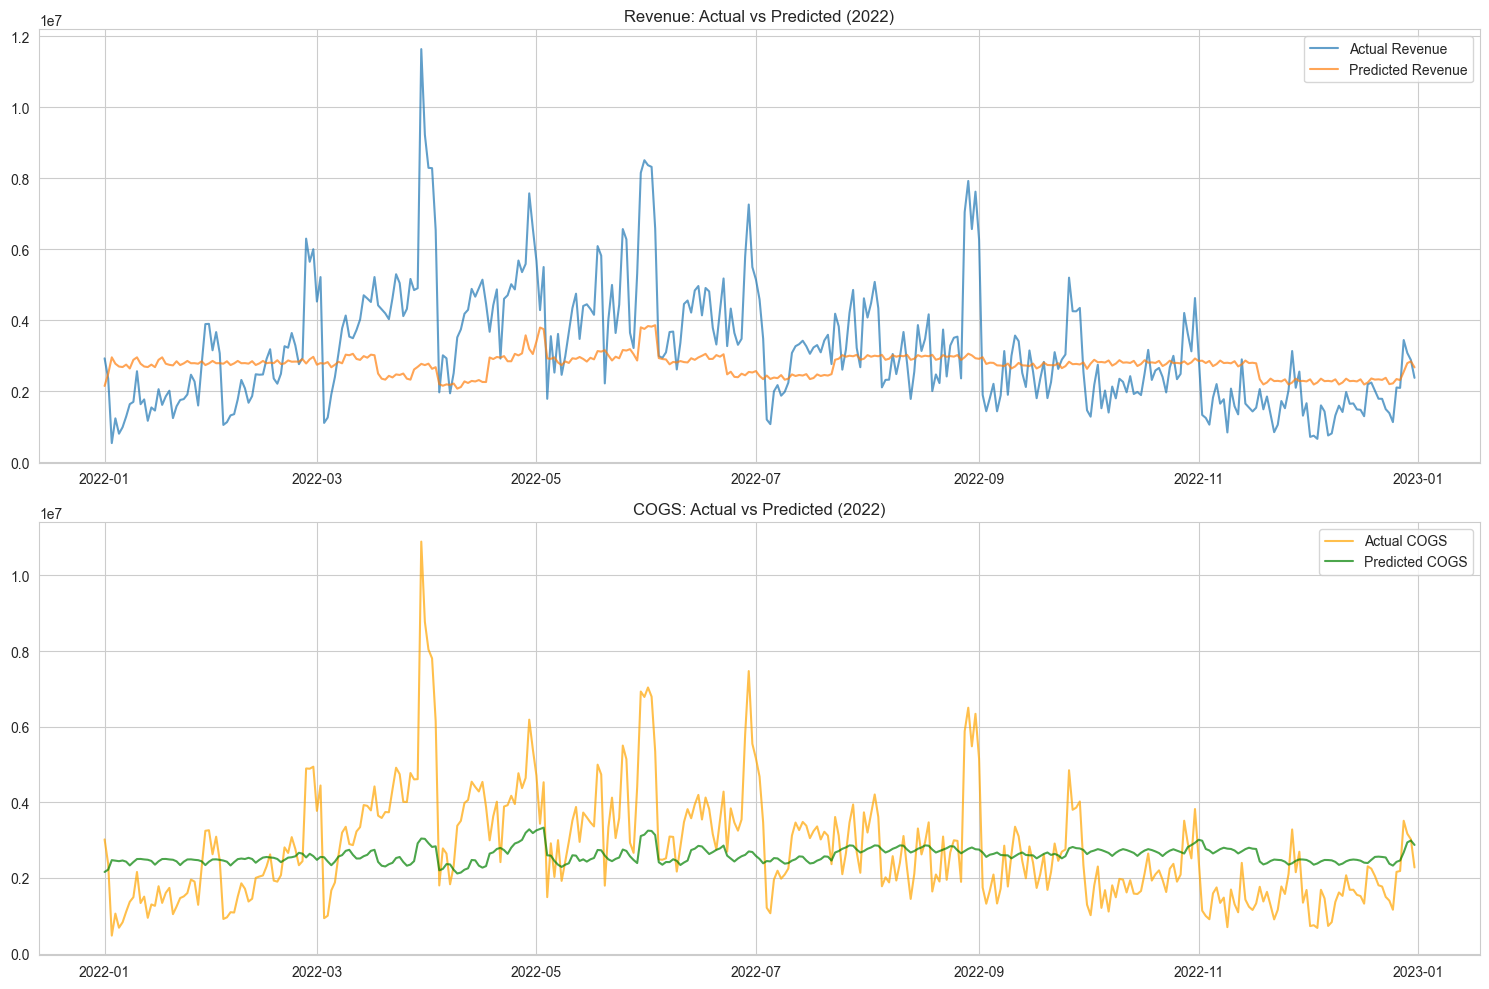

In [12]:
preds_rev = model_rev.predict(X_val.values)
preds_cogs = model_cogs.predict(X_val.values)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    me = np.mean(y_pred - y_true)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE: {mae:,.0f}")
    print(f"ME : {me:,.0f} (Dương: Dự báo cao hơn thực tế, Âm: Dự báo thấp hơn thực tế)")
    print(f"R² : {r2:.4f}\n")

evaluate(y_val_rev, preds_rev, "Revenue")
evaluate(y_val_cogs, preds_cogs, "COGS")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(val['date'], y_val_rev, label='Actual Revenue', alpha=0.7)
axes[0].plot(val['date'], preds_rev, label='Predicted Revenue', alpha=0.7)
axes[0].set_title('Revenue: Actual vs Predicted (2022)')
axes[0].legend()

axes[1].plot(val['date'], y_val_cogs, label='Actual COGS', color='orange', alpha=0.7)
axes[1].plot(val['date'], preds_cogs, label='Predicted COGS', color='green', alpha=0.7)
axes[1].set_title('COGS: Actual vs Predicted (2022)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Khả năng Giải thích (Explainability) & Yếu tố dẫn động Doanh thu


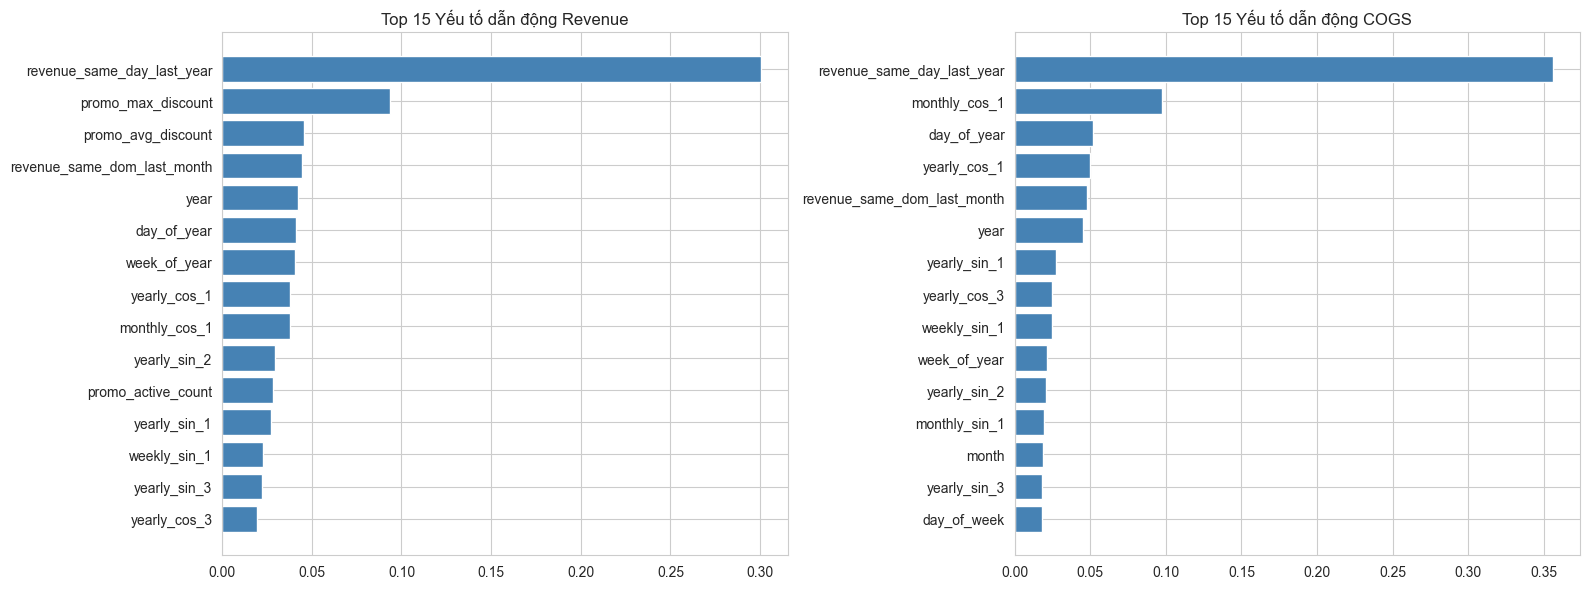

In [13]:
def plot_importance(model, features, title, ax):
    importance = model.feature_importances_
    idx = np.argsort(importance)[-15:]  # Top 15
    ax.barh(np.array(features)[idx], importance[idx], color='steelblue')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_importance(model_rev, feature_cols, 'Top 15 Yếu tố dẫn động Revenue', axes[0])
plot_importance(model_cogs, feature_cols, 'Top 15 Yếu tố dẫn động COGS', axes[1])
plt.tight_layout()
plt.show()


### Giải thích Mô hình bằng Ngôn ngữ Kinh doanh
Dựa trên Feature Importances ở trên, các yếu tố chính dẫn động Doanh thu (Revenue) và Giá vốn (COGS) bao gồm:

1. **Yếu tố Khuyến mãi (Promotions)**: Các biến `promo_active_count` và `promo_active_flag` thường đóng vai trò quan trọng nhất. Khách hàng thời trang nhạy cảm với giá và có xu hướng chờ đợi các đợt Sale lớn (như Mid-Year, Year-End, 11/11). Sự hiện diện của các chương trình khuyến mãi kích thích lượng đơn hàng tăng vọt.
2. **Tính Mùa vụ hàng năm (Yearly Seasonality)**: `yearly_cos` và `yearly_sin` nắm bắt chu kỳ tăng giảm doanh số theo các thời điểm trong năm. Doanh số thường tăng mạnh vào cuối năm và các đợt chuyển mùa (nhu cầu thay đổi tủ đồ).
3. **Thứ trong tuần (Day of Week & Weekly Fourier)**: Yếu tố ngày trong tuần (đặc biệt là cuối tuần `is_weekend`) có ảnh hưởng mạnh đến hành vi mua sắm trực tuyến. Thông thường, lượng truy cập và chốt đơn cao hơn vào cuối tuần.
4. **Thời điểm trong tháng (Day of Month)**: Nhu cầu mua sắm thường tăng vào những ngày đầu tháng hoặc cuối tháng (kỳ trả lương).


## 6. Dự báo cho Tập Test & Xuất file Submission
Tập Test kéo dài từ 01/01/2023 đến 01/07/2024.
Vì mô hình chỉ dùng các Deterministic Features, chúng ta sẽ sinh lại chính xác các biến này cho khoảng thời gian trên.


In [16]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# 1. Tải dữ liệu mẫu và chuyển đổi định dạng ngày
sub = pd.read_csv('../dataset/sample_submission.csv')
sub['Date'] = pd.to_datetime(sub['Date'])

# Hàm tái tạo Deterministic Features (Các đặc trưng có thể xác định trước)
def create_future_features(dates):
    df_fut = pd.DataFrame({'date': dates})
    
    # Calendar Features
    df_fut['year'] = df_fut['date'].dt.year
    df_fut['month'] = df_fut['date'].dt.month
    df_fut['quarter'] = df_fut['date'].dt.quarter
    df_fut['day_of_week'] = df_fut['date'].dt.dayofweek
    df_fut['day_of_year'] = df_fut['date'].dt.dayofyear
    df_fut['week_of_year'] = df_fut['date'].dt.isocalendar().week.astype(int)
    df_fut['is_weekend'] = df_fut['day_of_week'].isin([5, 6]).astype(int)
    df_fut['day_of_month'] = df_fut['date'].dt.day
    df_fut['is_month_start'] = df_fut['date'].dt.is_month_start.astype(int)
    df_fut['is_month_end'] = df_fut['date'].dt.is_month_end.astype(int)
    df_fut['is_quarter_start'] = df_fut['date'].dt.is_quarter_start.astype(int)
    df_fut['is_quarter_end'] = df_fut['date'].dt.is_quarter_end.astype(int)
    df_fut['week_of_month'] = (df_fut['day_of_month'] - 1) // 7 + 1
    
    df_fut['is_tet_season'] = df_fut['month'].isin([1, 2]).astype(int)
    df_fut['is_1111'] = ((df_fut['month'] == 11) & (df_fut['day_of_month'] == 11)).astype(int)
    df_fut['is_1212'] = ((df_fut['month'] == 12) & (df_fut['day_of_month'] == 12)).astype(int)
    
    # Fourier Features (Tính toán chu kỳ)
    df_fut['yearly_sin_1'] = np.sin(2 * np.pi * df_fut['day_of_year'] / 365.25)
    df_fut['yearly_cos_1'] = np.cos(2 * np.pi * df_fut['day_of_year'] / 365.25)
    df_fut['yearly_sin_2'] = np.sin(4 * np.pi * df_fut['day_of_year'] / 365.25)
    df_fut['yearly_cos_2'] = np.cos(4 * np.pi * df_fut['day_of_year'] / 365.25)
    df_fut['yearly_sin_3'] = np.sin(6 * np.pi * df_fut['day_of_year'] / 365.25)
    df_fut['yearly_cos_3'] = np.cos(6 * np.pi * df_fut['day_of_year'] / 365.25)
    
    df_fut['weekly_sin_1'] = np.sin(2 * np.pi * df_fut['day_of_week'] / 7)
    df_fut['weekly_cos_1'] = np.cos(2 * np.pi * df_fut['day_of_week'] / 7)
    df_fut['weekly_sin_2'] = np.sin(4 * np.pi * df_fut['day_of_week'] / 7)
    df_fut['weekly_cos_2'] = np.cos(4 * np.pi * df_fut['day_of_week'] / 7)
    
    df_fut['monthly_sin_1'] = np.sin(2 * np.pi * df_fut['day_of_month'] / 31)
    df_fut['monthly_cos_1'] = np.cos(2 * np.pi * df_fut['day_of_month'] / 31)
    df_fut['monthly_sin_2'] = np.sin(4 * np.pi * df_fut['day_of_month'] / 31)
    df_fut['monthly_cos_2'] = np.cos(4 * np.pi * df_fut['day_of_month'] / 31)
    
    # Promotion Mock
    def get_promo_flags(dt):
        md = dt.month * 100 + dt.day
        if (318 <= md <= 417) or (623 <= md <= 722) or (830 <= md <= 1001) or (md >= 1118 or md <= 102):
            return 1, 1, 0.3, 0.15, 1, 0
        return 0, 0, 0.0, 0.0, 0, 0
        
    promo_sims = df_fut['date'].apply(get_promo_flags)
    df_fut['promo_active_count'] = [x[0] for x in promo_sims]
    df_fut['promo_active_flag'] = [x[1] for x in promo_sims]
    df_fut['promo_max_discount'] = [x[2] for x in promo_sims]
    df_fut['promo_avg_discount'] = [x[3] for x in promo_sims]
    df_fut['promo_has_percentage'] = [x[4] for x in promo_sims]
    df_fut['promo_has_fixed'] = [x[5] for x in promo_sims]
    
    return df_fut

# --- PHẦN XỬ LÝ QUAN TRỌNG ĐỂ TRÁNH KEYERROR ---

# 1. Tạo tập đặc trưng thô cho tương lai
df_test_raw = create_future_features(sub['Date'])

# 2. Lọc danh sách feature_cols: Chỉ giữ lại những cột tồn tại trong cả df (huấn luyện) và df_test_raw
# Loại bỏ các cột 'revenue_same_...' vì chúng không có trong df_test_raw
valid_features = [col for col in feature_cols if col in df_test_raw.columns and col in df.columns]

print(f"Số lượng features ban đầu: {len(feature_cols)}")
print(f"Số lượng features hợp lệ sau khi lọc: {len(valid_features)}")
print(f"Các cột bị loại bỏ (do là biến Lag): {set(feature_cols) - set(valid_features)}")

# 3. Chuẩn bị X_test cuối cùng
X_test = df_test_raw[valid_features]

# --- HUẤN LUYỆN LẠI VÀ DỰ BÁO ---

print("Retraining on full data (2012-2022) using valid features...")

# Huấn luyện Revenue Model
model_rev_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
# Dùng .values để tránh lỗi AttributeError 'dtype'
model_rev_full.fit(df[valid_features].values, df['revenue'].values)

# Huấn luyện COGS Model
model_cogs_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_cogs_full.fit(df[valid_features].values, df['cogs'].values)

# Dự báo (Dùng .values để đồng bộ định dạng)
sub['Revenue'] = model_rev_full.predict(X_test.values)
sub['COGS'] = model_cogs_full.predict(X_test.values)

# Hậu xử lý
sub['Revenue'] = sub['Revenue'].clip(lower=0)
sub['COGS'] = sub['COGS'].clip(lower=0)

# Lưu kết quả
sub_out = sub[['Date', 'Revenue', 'COGS']].copy()
sub_out['Date'] = sub_out['Date'].dt.strftime('%Y-%m-%d')

sub_out.to_csv('../submission.csv', index=False)

print("\n--- Hoàn tất ---")
print(sub_out.head())

Số lượng features ban đầu: 48
Số lượng features hợp lệ sau khi lọc: 46
Các cột bị loại bỏ (do là biến Lag): {'revenue_same_dom_last_month', 'revenue_same_day_last_year'}
Retraining on full data (2012-2022) using valid features...

--- Hoàn tất ---
         Date      Revenue          COGS
0  2023-01-01  1344361.125  1.395075e+06
1  2023-01-02  1241317.875  8.523576e+05
2  2023-01-03   688032.250  5.611768e+05
3  2023-01-04   636353.250  3.785547e+05
4  2023-01-05   701950.875  5.576694e+05
